In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
states = ["S1", "S2", "S3", "S4"]

P = np.array([
    [0.20, 0.30, 0.30, 0.20],
    [0.10, 0.40, 0.20, 0.30],
    [0.25, 0.25, 0.25, 0.25],
    [0.30, 0.20, 0.10, 0.40]
], dtype=float)

print("Матрица переходных вероятностей P:")
print(P)

print("\nСуммы элементов в строках:")
print(P.sum(axis=1))

Матрица переходных вероятностей P:
[[0.2  0.3  0.3  0.2 ]
 [0.1  0.4  0.2  0.3 ]
 [0.25 0.25 0.25 0.25]
 [0.3  0.2  0.1  0.4 ]]

Суммы элементов в строках:
[1. 1. 1. 1.]


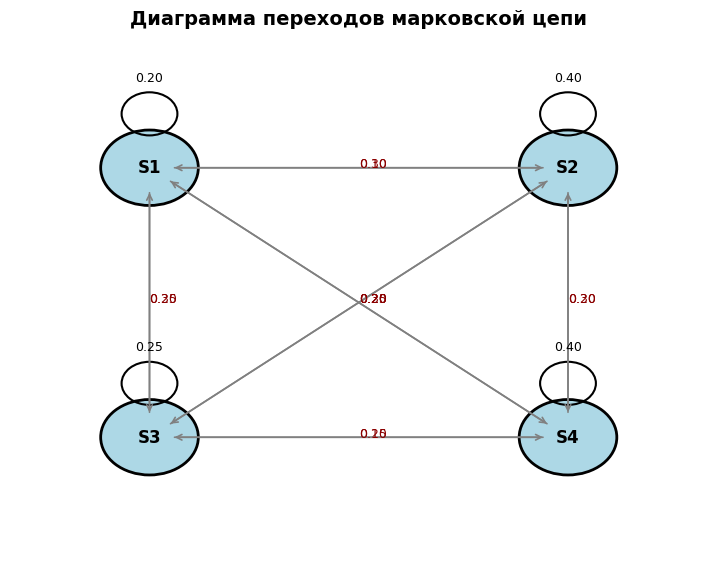

In [17]:
def draw_markov_chain(states, P):
    plt.figure(figsize=(9, 7))
    ax = plt.gca()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    positions = {
        "S1": (0.2, 0.75),
        "S2": (0.8, 0.75),
        "S3": (0.2, 0.25),
        "S4": (0.8, 0.25)
    }

    for s in states:
        x, y = positions[s]
        circle = plt.Circle((x, y), 0.07, color="lightblue", ec="black", lw=2)
        ax.add_patch(circle)
        ax.text(x, y, s, ha="center", va="center", fontsize=12, fontweight="bold")

    for i, s_from in enumerate(states):
        x1, y1 = positions[s_from]
        for j, s_to in enumerate(states):
            prob = P[i, j]
            if prob <= 0:
                continue

            x2, y2 = positions[s_to]

            if s_from == s_to:
                loop = plt.Circle((x1, y1 + 0.10), 0.04, fill=False, ec="black", lw=1.5)
                ax.add_patch(loop)
                ax.text(x1, y1 + 0.16, f"{prob:.2f}", ha="center", fontsize=9)
            else:
                dx = x2 - x1
                dy = y2 - y1
                ax.annotate(
                    "",
                    xy=(x2, y2),
                    xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.2, color="gray",
                                    shrinkA=18, shrinkB=18)
                )
                mx, my = (x1 + x2) / 2, (y1 + y2) / 2
                ax.text(mx, my, f"{prob:.2f}", fontsize=9, color="darkred")

    plt.title("Диаграмма переходов марковской цепи", fontsize=14, fontweight="bold")
    plt.show()

draw_markov_chain(states, P)

In [18]:
initial_vectors = {
    "v1 = [1, 0, 0, 0]": np.array([1.0, 0.0, 0.0, 0.0]),
    "v2 = [0, 1, 0, 0]": np.array([0.0, 1.0, 0.0, 0.0]),
    "v3 = [0, 0, 0, 1]": np.array([0.0, 0.0, 0.0, 1.0]),
    "v4 = [0.25, 0.25, 0.25, 0.25]": np.array([0.25, 0.25, 0.25, 0.25])
}

eps = 1e-6
max_steps = 1000

In [19]:
def rms_diff(old_vec, new_vec):
    return np.sqrt(np.mean((new_vec - old_vec) ** 2))

def simulate_markov_chain(P, p0, eps=1e-6, max_steps=1000, store_history=True):
    old_vec = p0.copy()

    if store_history:
        history = [old_vec.copy()]
    else:
        history = None

    rms_history = []

    for step in range(max_steps):
        new_vec = old_vec @ P
        err = rms_diff(old_vec, new_vec)
        rms_history.append(err)

        if store_history:
            history.append(new_vec.copy())

        if err < eps:
            return {
                "final_vec": new_vec,
                "steps": step + 1,
                "history": np.array(history) if store_history else None,
                "rms_history": np.array(rms_history)
            }

        old_vec = new_vec

    return {
        "final_vec": old_vec,
        "steps": max_steps,
        "history": np.array(history) if store_history else None,
        "rms_history": np.array(rms_history)
    }

In [20]:
results = {}

for name, p0 in initial_vectors.items():
    result = simulate_markov_chain(P, p0, eps=eps, max_steps=max_steps, store_history=True)
    results[name] = result

    print(name)
    print("Начальный вектор :", p0)
    print("Конечный вектор  :", np.round(result["final_vec"], 8))
    print("Число шагов      :", result["steps"])
    print("-" * 60)

v1 = [1, 0, 0, 0]
Начальный вектор : [1. 0. 0. 0.]
Конечный вектор  : [0.21103899 0.28896101 0.20129859 0.29870141]
Число шагов      : 8
------------------------------------------------------------
v2 = [0, 1, 0, 0]
Начальный вектор : [0. 1. 0. 0.]
Конечный вектор  : [0.21103907 0.28896093 0.20129875 0.29870125]
Число шагов      : 8
------------------------------------------------------------
v3 = [0, 0, 0, 1]
Начальный вектор : [0. 0. 0. 1.]
Конечный вектор  : [0.21103885 0.28896115 0.20129878 0.29870122]
Число шагов      : 8
------------------------------------------------------------
v4 = [0.25, 0.25, 0.25, 0.25]
Начальный вектор : [0.25 0.25 0.25 0.25]
Конечный вектор  : [0.21103893 0.28896107 0.20129863 0.29870137]
Число шагов      : 7
------------------------------------------------------------


In [21]:
summary_rows = []

for name, data in results.items():
    summary_rows.append([
        name,
        data["steps"],
        *np.round(data["final_vec"], 8)
    ])

print("Таблица конечных векторов:")
print("Начальный вектор | Шаги | S1 | S2 | S3 | S4")
for row in summary_rows:
    print(row)

Таблица конечных векторов:
Начальный вектор | Шаги | S1 | S2 | S3 | S4
['v1 = [1, 0, 0, 0]', 8, np.float64(0.21103899), np.float64(0.28896101), np.float64(0.20129859), np.float64(0.29870141)]
['v2 = [0, 1, 0, 0]', 8, np.float64(0.21103907), np.float64(0.28896093), np.float64(0.20129875), np.float64(0.29870125)]
['v3 = [0, 0, 0, 1]', 8, np.float64(0.21103885), np.float64(0.28896115), np.float64(0.20129878), np.float64(0.29870122)]
['v4 = [0.25, 0.25, 0.25, 0.25]', 7, np.float64(0.21103893), np.float64(0.28896107), np.float64(0.20129863), np.float64(0.29870137)]


In [22]:
import pandas as pd

df_summary = pd.DataFrame(
    summary_rows,
    columns=["Initial vector", "Steps", "S1", "S2", "S3", "S4"]
)
df_summary

,Initial vector,Steps,S1,S2,S3,S4
0,"v1 = [1, 0, 0, 0]",8,0.211039,0.288961,0.201299,0.298701
1,"v2 = [0, 1, 0, 0]",8,0.211039,0.288961,0.201299,0.298701
2,"v3 = [0, 0, 0, 1]",8,0.211039,0.288961,0.201299,0.298701
3,"v4 = [0.25, 0.25, 0.25, 0.25]",7,0.211039,0.288961,0.201299,0.298701


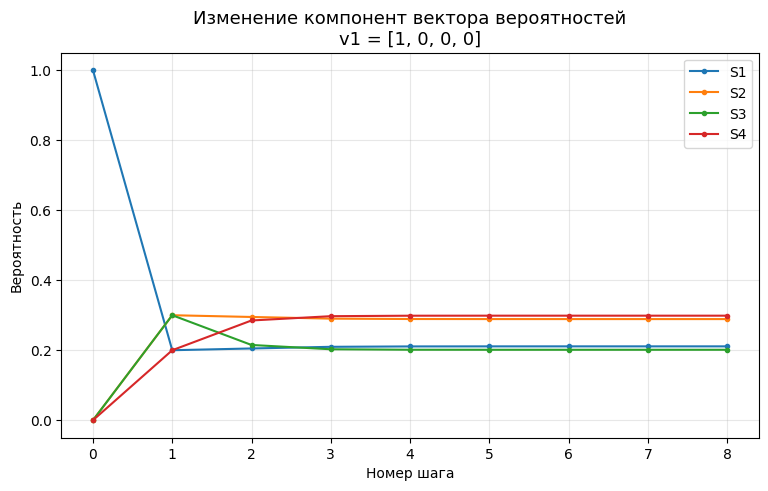

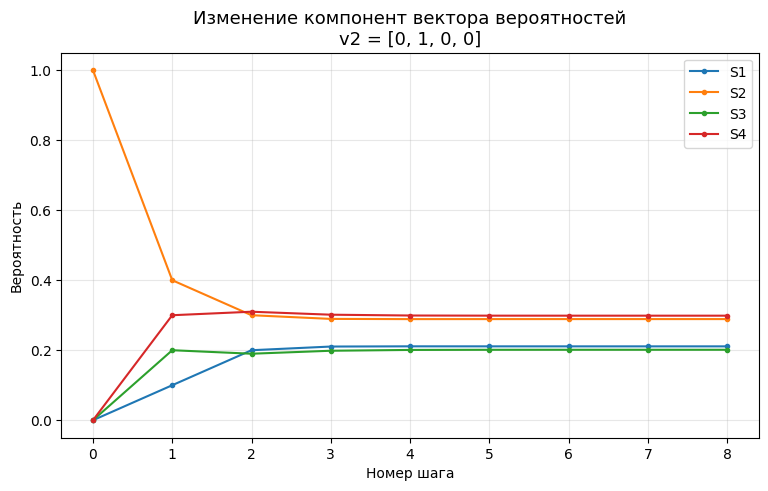

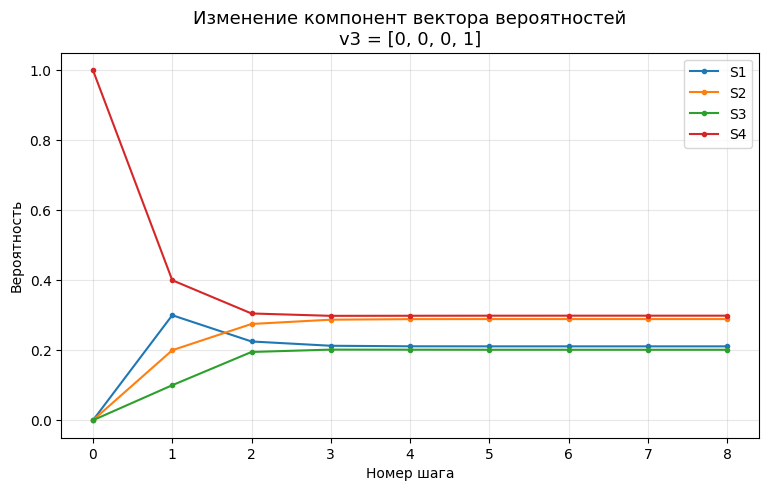

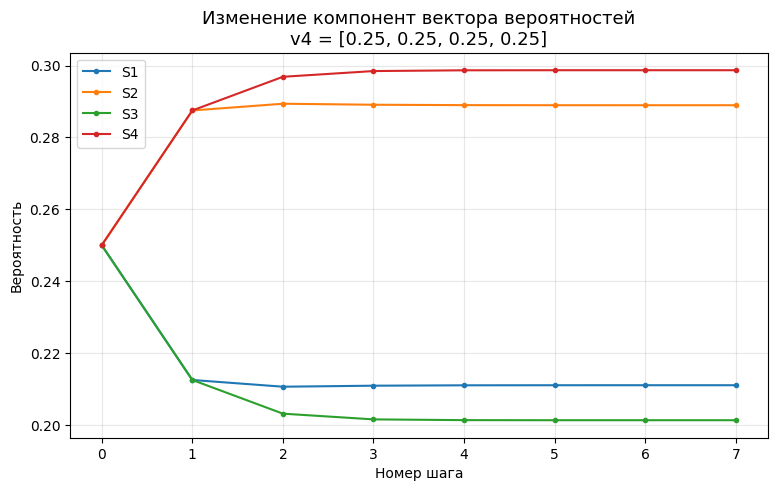

In [23]:
state_labels = ["S1", "S2", "S3", "S4"]

for name, data in results.items():
    history = data["history"]
    steps_axis = np.arange(history.shape[0])

    plt.figure(figsize=(9, 5))
    for i in range(history.shape[1]):
        plt.plot(steps_axis, history[:, i], marker='o', markersize=3, label=state_labels[i])

    plt.title(f"Изменение компонент вектора вероятностей\n{name}", fontsize=13)
    plt.xlabel("Номер шага")
    plt.ylabel("Вероятность")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

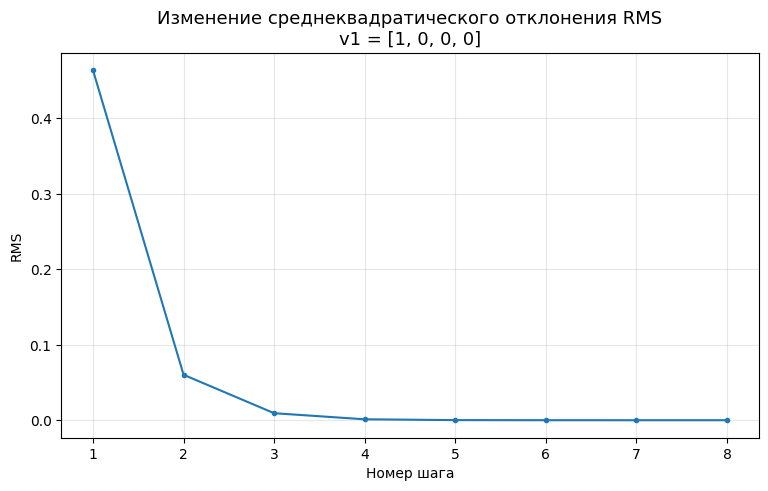

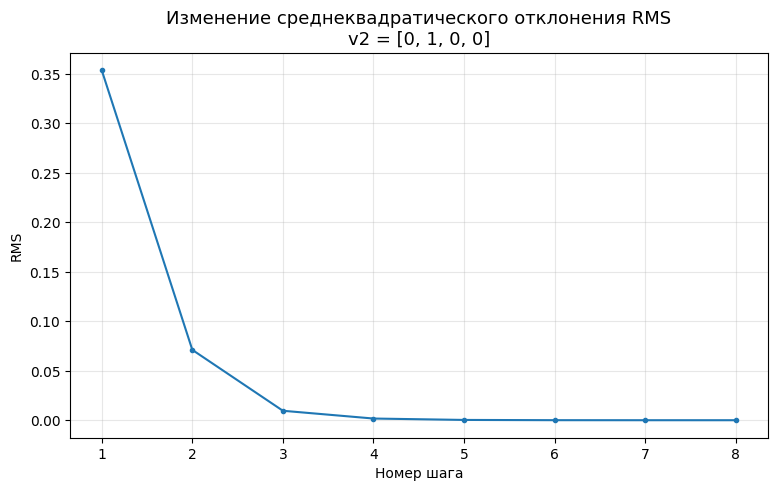

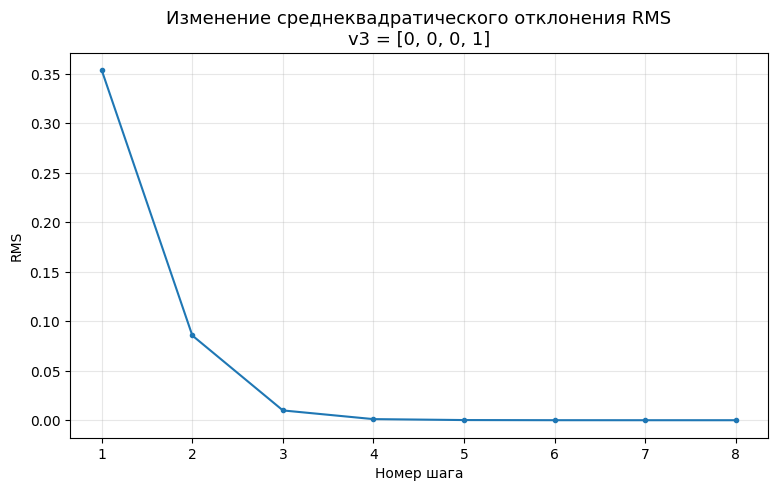

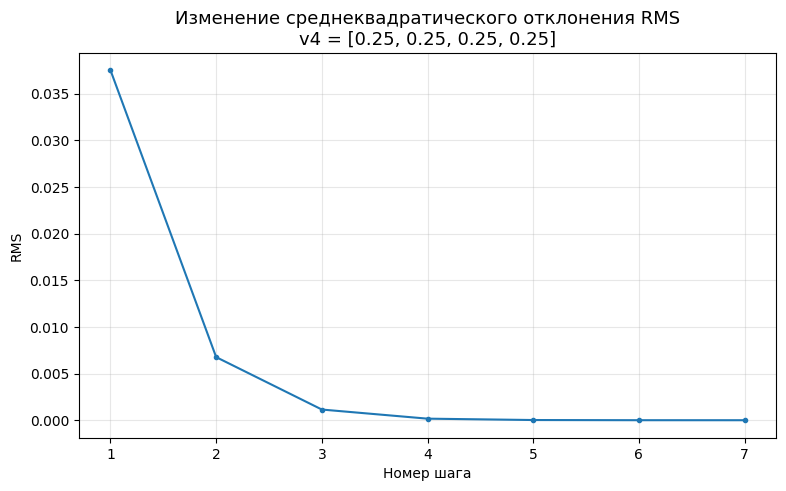

In [24]:
for name, data in results.items():
    rms_history = data["rms_history"]
    steps_axis = np.arange(1, len(rms_history) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(steps_axis, rms_history, marker='o', markersize=3)
    plt.title(f"Изменение среднеквадратического отклонения RMS\n{name}", fontsize=13)
    plt.xlabel("Номер шага")
    plt.ylabel("RMS")
    plt.grid(True, alpha=0.3)
    plt.show()

In [25]:
n = P.shape[0]

A = P.T - np.eye(n)
A[-1] = np.ones(n)
b = np.zeros(n)
b[-1] = 1.0

pi_stationary = np.linalg.solve(A, b)

print("Стационарное распределение (аналитически):")
print(np.round(pi_stationary, 8))

print("\nПроверка:")
print("Сумма компонент =", pi_stationary.sum())
print("pi * P =", np.round(pi_stationary @ P, 8))

Стационарное распределение (аналитически):
[0.21103896 0.28896104 0.2012987  0.2987013 ]

Проверка:
Сумма компонент = 1.0
pi * P = [0.21103896 0.28896104 0.2012987  0.2987013 ]


In [26]:
comparison_rows = []

for name, data in results.items():
    final_vec = data["final_vec"]
    diff = np.linalg.norm(final_vec - pi_stationary)

    comparison_rows.append([
        name,
        *np.round(final_vec, 8),
        np.round(diff, 10)
    ])

df_comparison = pd.DataFrame(
    comparison_rows,
    columns=["Initial vector", "S1", "S2", "S3", "S4", "||final - pi||"]
)

df_comparison

,Initial vector,S1,S2,S3,S4,||final - pi||
0,"v1 = [1, 0, 0, 0]",0.211039,0.288961,0.201299,0.298701,1.677000e-07
1,"v2 = [0, 1, 0, 0]",0.211039,0.288961,0.201299,0.298701,1.698000e-07
2,"v3 = [0, 0, 0, 1]",0.211039,0.288961,0.201299,0.298701,1.939000e-07
3,"v4 = [0.25, 0.25, 0.25, 0.25]",0.211039,0.288961,0.201299,0.298701,1.143000e-07


In [27]:
rng = np.random.default_rng(42)

def random_trajectory(states, P, start_state, steps=10):
    state_to_idx = {s: i for i, s in enumerate(states)}
    idx_to_state = {i: s for i, s in enumerate(states)}

    current = state_to_idx[start_state]
    trajectory = [start_state]

    for _ in range(steps):
        current = rng.choice(len(states), p=P[current])
        trajectory.append(idx_to_state[current])

    return trajectory

traj = random_trajectory(states, P, start_state="S1", steps=12)
print("Случайная траектория:")
print(" -> ".join(traj))

Случайная траектория:
S1 -> S3 -> S2 -> S4 -> S4 -> S1 -> S4 -> S4 -> S4 -> S1 -> S2 -> S2 -> S4
